### This is the file which we used in some of our models to get the functions for secondary eclipses. This was made using ```batman``` package.
This file does not contain any planet parameter fitting, but this file just contain the required functions and formalism for secondary eclipse modeling

True secondary time: 0.501
Priors:
---------
{'P_p1': {'distribution': 'fixed', 'hyperparameters': 1.0}, 't0_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'b_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'ecc_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'omega_p1': {'distribution': 'fixed', 'hyperparameters': 90.0}, 'p_p1': {'distribution': 'uniform', 'hyperparameters': [0.0, 0.2]}, 'a_p1': {'distribution': 'normal', 'hyperparameters': [3.6, 0.1]}, 'mdilution_inst': {'distribution': 'fixed', 'hyperparameters': 1.0}, 'mflux_inst': {'distribution': 'normal', 'hyperparameters': [0.0, 0.1]}, 'sigma_w_inst': {'distribution': 'loguniform', 'hyperparameters': [0.1, 1000.0]}, 'fp_p1': {'distribution': 'uniform', 'hyperparameters': [0.0, 0.1]}, 't_secondary_p1': {'distribution': 'normal', 'hyperparameters': [0.5, 0.1]}}
	 Eclipse fit detected for instrument  inst
	 >> ecc,omega parametrization detected for lc planet p1
PyMultinest installation not detected. Forcin

20202it [01:02, 324.70it/s, +500 | bound: 246 | nc: 1 | ncall: 496420 | eff(%):  4.174 | loglstar:   -inf < 2346.403 <    inf | logz: 2306.659 +/-  0.281 | dlogz:  0.001 >  0.509] 


START 
 testing:
True
dict_keys(['unnamed', 'loglike', 'p_p1', 'a_p1', 'mflux_inst', 'sigma_w_inst', 'fp_p1', 't_secondary_p1'])


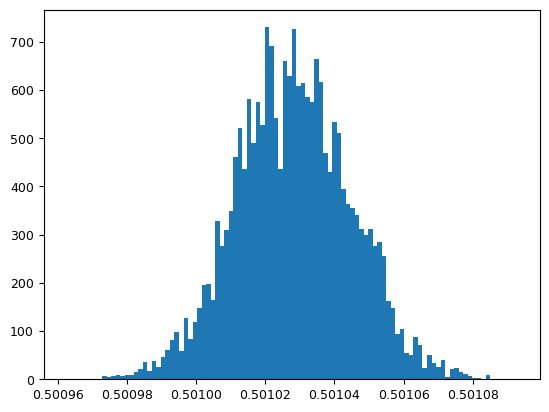

0.5010280540531886
END


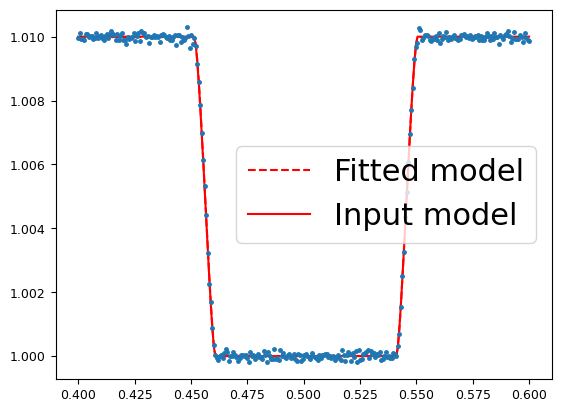

In [2]:

import matplotlib.pyplot as plt
import time
import numpy as np
import random

import juliet
import batman

random.seed(42)

# Create dataset:
def get_transit_model(n = 300):
    params = batman.TransitParams()
    params.t0 = 0.0   # time of inferior conjunction
    params.per = 1.0  # orbital period (days)
    params.a = 3.6    # semi-major axis (in units of stellar radii)
    params.rp = 0.1   # rp/rs
    params.inc = 90.  # orbital inclination (in degrees)
    params.ecc = 0.   # eccentricity
    params.w = 90.    # longitude of periastron (in degrees) p
    params.limb_dark = 'quadratic' # limb darkening profile to use
    params.u = [0.2,0.3] # limb darkening coefficients
    params.fp = 0.01
    params.ac = 0.001
    params.t_secondary = params.t0 + params.per*0.5 + params.ac
    print('True secondary time:', params.t_secondary)
    t = np.linspace(-0.1,0.1,n) + 0.5
    tmodel = batman.TransitModel(params, t.astype('float64'), transittype='secondary')
    return t, tmodel.light_curve(params)

# Set number of datapoints the lightcurve will have; define dictionaries 
# that will host the data:
n = 300
times, fluxes, errors = {}, {}, {}

# Get data, add noise, put it in the dictionaries. Note sigma is underestimated:
times['inst'], tmodel = get_transit_model(n)
sigma = 100*1e-6
fluxes['inst'], errors['inst'] = tmodel + np.random.normal(0., sigma, n), np.ones(300)*sigma*0.1

# Define priors:
params = ['P_p1','t0_p1', 'b_p1','ecc_p1','omega_p1', 'p_p1',\
          'a_p1', 'mdilution_inst', 'mflux_inst', 'sigma_w_inst', 'fp_p1', 't_secondary_p1']

# Distributions:
dists = ['fixed','fixed','fixed','fixed','fixed', 'uniform',\
         'normal', 'fixed', 'normal', 'loguniform', 'uniform', 'normal']

# Hyperparameters
hyperps = [1.0, 0.0, 0.0, 0.0, 90., [0.,0.2],\
           [3.6,0.1], 1.0, [0.,0.1], [0.1, 1000.], [0.,0.1], [0.5,0.1]]

# Join priors:
priors = juliet.generate_priors(params,dists,hyperps)

print('Priors:')
print('---------')
print(priors)
# And fit:
sampler = 'multinest'
    
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = errors, out_folder = 'eclipse-test', verbose = True)
results = dataset.fit(sampler = sampler, progress = True)

print('START \n testing:')
print(results.lc.dictionary['inst']['EclipseFit'])
print(results.lc.posteriors.keys())
plt.hist(results.lc.posteriors['t_secondary_p1'], bins = 100)
plt.show()
print(np.median(results.lc.posteriors['t_secondary_p1']))
print('END')
model = results.lc.evaluate('inst')
plt.errorbar(times['inst'], fluxes['inst'], errors['inst'], fmt = '.')
plt.plot(times['inst'], model, 'r--', label = 'Fitted model')
plt.plot(times['inst'], tmodel, 'r-', label = 'Input model')

plt.legend(fontsize=22)
plt.show()


True secondary time: 0.5
Priors:
---------
{'P_p1': {'distribution': 'fixed', 'hyperparameters': 1.0}, 't0_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'b_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'ecc_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'omega_p1': {'distribution': 'fixed', 'hyperparameters': 90.0}, 'p_p1_inst': {'distribution': 'uniform', 'hyperparameters': [0.0, 0.3]}, 'p_p1_inst2': {'distribution': 'uniform', 'hyperparameters': [0.0, 0.3]}, 'q1_inst_inst2': {'distribution': 'uniform', 'hyperparameters': [0.0, 1.0]}, 'q2_inst_inst2': {'distribution': 'uniform', 'hyperparameters': [0.0, 1.0]}, 'a_p1': {'distribution': 'normal', 'hyperparameters': [3.6, 0.1]}, 'mdilution_inst_inst2': {'distribution': 'fixed', 'hyperparameters': 1.0}, 'mflux_inst': {'distribution': 'normal', 'hyperparameters': [0.0, 0.1]}, 'sigma_w_inst': {'distribution': 'loguniform', 'hyperparameters': [0.1, 1000.0]}, 'fp_p1': {'distribution': 'uniform', 'hyperparameters':

38378it [03:45, 169.98it/s, +500 | bound: 491 | nc: 1 | ncall: 1154490 | eff(%):  3.369 | loglstar:   -inf < 7053.045 <    inf | logz: 6976.885 +/-  0.391 | dlogz:  0.001 >  0.509] 


START 
 testing:
False
dict_keys(['unnamed', 'loglike', 'p_p1_inst', 'p_p1_inst2', 'q1_inst_inst2', 'q2_inst_inst2', 'a_p1', 'mflux_inst', 'sigma_w_inst', 'fp_p1', 't_secondary_p1', 'mflux_inst2', 'sigma_w_inst2'])


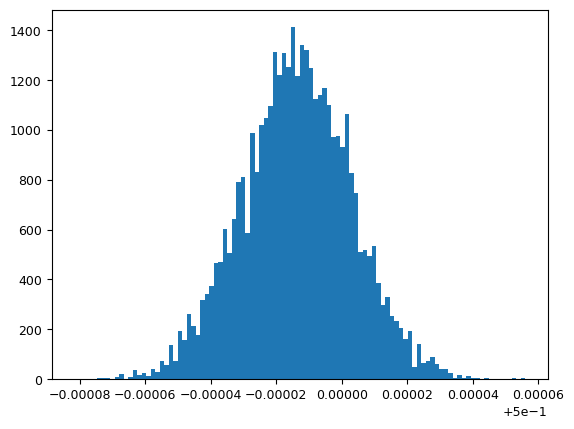

0.49998630687098544
END


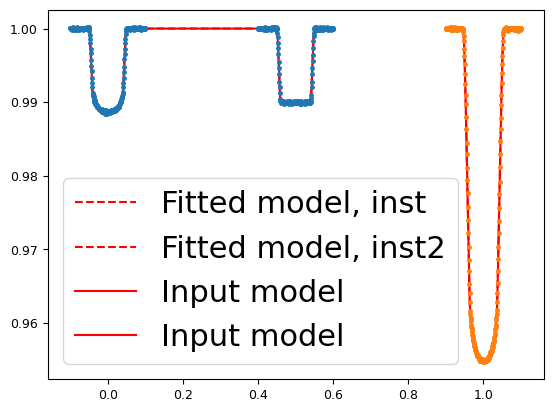

In [6]:
random.seed(42)

# Create dataset:
def get_eclipse_model(n = 300, fp = 0.01):
    params = batman.TransitParams()
    params.t0 = 0.0   # time of inferior conjunction
    params.per = 1.0  # orbital period (days)
    params.a = 3.6    # semi-major axis (in units of stellar radii)
    params.rp = 0.1   # rp/rs
    params.inc = 90.  # orbital inclination (in degrees)
    params.ecc = 0.   # eccentricity
    params.w = 90.    # longitude of periastron (in degrees) p
    params.limb_dark = 'quadratic' # limb darkening profile to use
    params.u = [0.2,0.3] # limb darkening coefficients
    params.fp = fp
    params.ac = 0.0
    params.t_secondary = params.t0 + params.per*0.5 + params.ac
    print('True secondary time:', params.t_secondary)
    t = np.linspace(-0.1,0.1,n) + 0.5
    tmodel = batman.TransitModel(params, t.astype('float64'), transittype='secondary')
    return t, tmodel.light_curve(params)

def get_transit_model(n = 300, p = 0.1, t0 = 0.):
    params = batman.TransitParams()
    params.t0 = t0   # time of inferior conjunction
    params.per = 1.0  # orbital period (days)
    params.a = 3.6    # semi-major axis (in units of stellar radii)
    params.rp = p   # rp/rs
    params.inc = 90.  # orbital inclination (in degrees)
    params.ecc = 0.   # eccentricity
    params.w = 90.    # longitude of periastron (in degrees) p
    params.limb_dark = 'quadratic' # limb darkening profile to use
    params.u = [0.2,0.3] # limb darkening coefficients
    t = np.linspace(-0.1,0.1,n) + t0 
    tmodel = batman.TransitModel(params, t.astype('float64'))
    return t, tmodel.light_curve(params)

# Set number of datapoints the lightcurve will have; define dictionaries 
# that will host the data:
n = 300
times, fluxes, errors = {}, {}, {}

# Get data, add noise, put it in the dictionaries. Note sigma is underestimated:
fp = 0.01
te, emodel = get_eclipse_model(n, fp = fp)
emodel = emodel - fp

tt, tmodel = get_transit_model(n)

times['inst'], tmodel = np.append(tt,te), np.append(tmodel, emodel)

# Generate yet another dataset but with a different depth and transit time:
times['inst2'], tmodel2 = get_transit_model(n, p = 0.2, t0 = 1.0)

sigma = 100*1e-6
fluxes['inst'], errors['inst'] = tmodel + np.random.normal(0., sigma, len(tmodel)), np.ones(len(tmodel))*sigma*0.1
fluxes['inst2'], errors['inst2'] = tmodel2 + np.random.normal(0., sigma, len(tmodel2)), np.ones(len(tmodel2))*sigma*0.1

# Define priors:
params = ['P_p1','t0_p1', 'b_p1','ecc_p1','omega_p1', 'p_p1_inst', 'p_p1_inst2', 'q1_inst_inst2', 'q2_inst_inst2',\
          'a_p1', 'mdilution_inst_inst2', 'mflux_inst', 'sigma_w_inst', 'fp_p1', 't_secondary_p1', \
          'mflux_inst2', 'sigma_w_inst2']

# Distributions:
dists = ['fixed','fixed','fixed','fixed','fixed', 'uniform','uniform','uniform','uniform',\
         'normal', 'fixed', 'normal', 'loguniform', 'uniform', 'normal', \
         'normal', 'loguniform']

# Hyperparameters
hyperps = [1.0, 0.0, 0.0, 0.0, 90., [0.,0.3], [0.,0.3], [0., 1.], [0., 1.],\
           [3.6,0.1], 1.0, [0.,0.1], [0.1, 1000.], [0.,0.1], [0.5,0.1],\
           [0.,0.1], [0.1, 1000.]]

# Join priors:
priors = juliet.generate_priors(params,dists,hyperps)

print('Priors:')
print('---------')
print(priors)
# And fit:
sampler = 'multinest'
    
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = errors, out_folder = 'transit-and-eclipse-test', verbose = True)
results = dataset.fit(sampler = sampler, progress = True)

print('START \n testing:')
print(results.lc.dictionary['inst']['EclipseFit'])
print(results.lc.posteriors.keys())
plt.hist(results.lc.posteriors['t_secondary_p1'], bins = 100)
plt.show()
print(np.median(results.lc.posteriors['t_secondary_p1']))
print('END')
model = results.lc.evaluate('inst')
model2 = results.lc.evaluate('inst2')
plt.errorbar(times['inst'], fluxes['inst'], errors['inst'], fmt = '.')
plt.errorbar(times['inst2'], fluxes['inst2'], errors['inst2'], fmt = '.')
plt.plot(times['inst'], model, 'r--', label = 'Fitted model, inst')
plt.plot(times['inst2'], model2, 'r--', label = 'Fitted model, inst2')
plt.plot(times['inst'], tmodel, 'r-', label = 'Input model')
plt.plot(times['inst2'], tmodel2, 'r-', label = 'Input model')

plt.legend(fontsize=22)
plt.show()

True secondary time: 0.25
Period = 0.5, t0 = 0.0


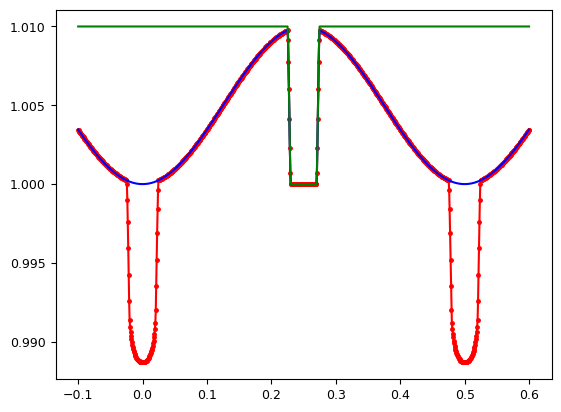

Priors:
---------
{'P_p1': {'distribution': 'fixed', 'hyperparameters': 0.5}, 't0_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'b_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'ecc_p1': {'distribution': 'fixed', 'hyperparameters': 0.0}, 'omega_p1': {'distribution': 'fixed', 'hyperparameters': 90.0}, 'p_p1': {'distribution': 'uniform', 'hyperparameters': [0.0, 0.3]}, 'q1_inst': {'distribution': 'uniform', 'hyperparameters': [0.0, 1.0]}, 'q2_inst': {'distribution': 'uniform', 'hyperparameters': [0.0, 1.0]}, 'a_p1': {'distribution': 'normal', 'hyperparameters': [3.6, 0.1]}, 'mdilution_inst': {'distribution': 'fixed', 'hyperparameters': 1.0}, 'mflux_inst': {'distribution': 'normal', 'hyperparameters': [0.0, 0.1]}, 'sigma_w_inst': {'distribution': 'loguniform', 'hyperparameters': [0.1, 1000.0]}, 'fp_p1': {'distribution': 'uniform', 'hyperparameters': [0.0, 0.1]}, 't_secondary_p1': {'distribution': 'normal', 'hyperparameters': [0.25, 0.1]}, 'phaseoffset_p1': {'distributi

26154it [01:53, 230.93it/s, +500 | bound: 325 | nc: 1 | ncall: 700074 | eff(%):  3.810 | loglstar:   -inf < 7789.677 <    inf | logz: 7738.010 +/-  0.324 | dlogz:  0.001 >  0.509] 


START 
 testing:
False
dict_keys(['unnamed', 'loglike', 'p_p1', 'q1_inst', 'q2_inst', 'a_p1', 'mflux_inst', 'sigma_w_inst', 'fp_p1', 't_secondary_p1'])


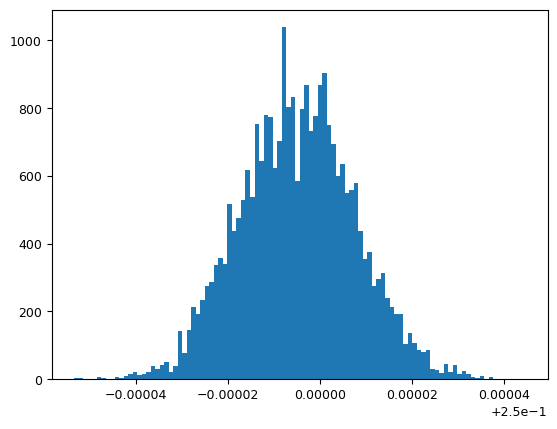

0.2499952625479811
END


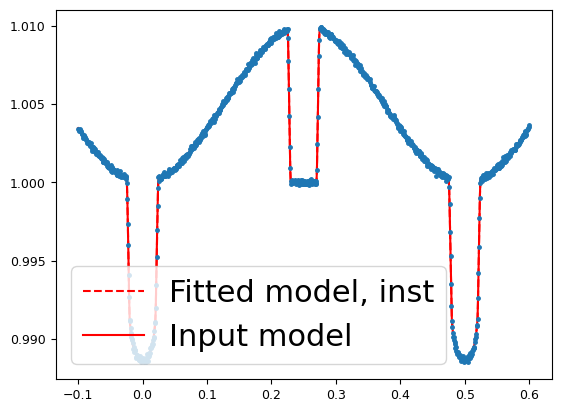

In [ ]:
random.seed(42)

# Create dataset:
def get_eclipse_model(n = 300, fp = 0.01, t0 = 0., per = 1.0):
    params = batman.TransitParams()
    params.t0 = t0   # time of inferior conjunction
    params.per = per  # orbital period (days)
    params.a = 3.6    # semi-major axis (in units of stellar radii)
    params.rp = 0.1   # rp/rs
    params.inc = 90.  # orbital inclination (in degrees)
    params.ecc = 0.   # eccentricity
    params.w = 90.    # longitude of periastron (in degrees) p
    params.limb_dark = 'quadratic' # limb darkening profile to use
    params.u = [0.2,0.3] # limb darkening coefficients
    params.fp = fp
    params.ac = 0.0
    params.t_secondary = params.t0 + params.per*0.5 + params.ac
    print('True secondary time:', params.t_secondary)
    t = np.linspace(t0-0.1,t0+per+0.1,n) + t0 
    tmodel = batman.TransitModel(params, t.astype('float64'), transittype='secondary')
    return t, tmodel.light_curve(params)

def get_transit_model(n = 300, p = 0.1, t0 = 0., per = 1.0):
    params = batman.TransitParams()
    params.t0 = t0   # time of inferior conjunction
    params.per = per  # orbital period (days)
    params.a = 3.6    # semi-major axis (in units of stellar radii)
    params.rp = p   # rp/rs
    params.inc = 90.  # orbital inclination (in degrees)
    params.ecc = 0.   # eccentricity
    params.w = 90.    # longitude of periastron (in degrees) p
    params.limb_dark = 'quadratic' # limb darkening profile to use
    params.u = [0.2,0.3] # limb darkening coefficients
    t = np.linspace(t0-0.1,t0+per+0.1,n) + t0 
    tmodel = batman.TransitModel(params, t.astype('float64'))
    return t, tmodel.light_curve(params)

# Set number of datapoints the lightcurve will have; define dictionaries 
# that will host the data:
per = 0.5
t0 = 0.0
tsec = t0 + per*0.5
n = 1000
times, fluxes, errors = {}, {}, {}

# Get data, add noise, put it in the dictionaries. Note sigma is underestimated:
fp = 0.01
te, emodel = get_eclipse_model(n, fp = fp, per = per, t0 = t0)
#emodel = emodel - fp

tt, tmodel = get_transit_model(n, per = per, t0 = t0)

# Generate sinusoid:
A = fp * 1e6#1000#3.*fp*1e6#100 # in ppm
phase_offset = 0.#50.0 # in degrees

print('Period = {p}, t0 = {t0}'.format(p = per, t0 = t0))
orbital_phase = ( ( ( tt - t0 ) / per ) % 1 )
center_phase = - np.pi / 2. 
#sine_model = 1. + (A*1e-6) * np.sin(2. * np.pi * (orbital_phase) + center_phase + phase_offset * (np.pi / 180.) )

sine_model = np.sin(2. * np.pi * (orbital_phase) + center_phase + phase_offset * (np.pi / 180.) )

# Scale to be 1 at secondary eclipse, 0 at transit:
sine_model = (sine_model + 1) * 0.5

# Amplify by A in ppm:
sine_model = (A*1e-6) * sine_model

# Multiply by normed eclipse model; add one:
sine_model = 1. + sine_model * ((emodel - 1.) / fp)

# Now make way for eclipse model:
#idx = np.where(emodel != 1. + fp) 
#sine_model[idx] = emodel[idx]# / np.mean(sine_model[idx])
# Find points not-in-eclipse:
#idx = np.where(emodel != 1.)

# Re-scale sine model to match eclipse model depth:
planet_model = tmodel * sine_model #(emodel-1.0) * sine_model
#sine_model
#emodel[idx] = ( emodel[idx] / (1. + fp) ) * np.mean(sine_model[idx])
#sine_model[idx] = 0.

times['inst'], tmodel = tt, planet_model

plt.plot(times['inst'], tmodel, 'r.-')
plt.plot(times['inst'], sine_model, 'b-')
plt.plot(times['inst'], emodel, 'g-')

plt.show()

tmodel = planet_model

sigma = 100*1e-6
fluxes['inst'], errors['inst'] = tmodel + np.random.normal(0., sigma, len(tmodel)), np.ones(len(tmodel))*sigma*0.1

# Define priors:
params = ['P_p1','t0_p1', 'b_p1','ecc_p1','omega_p1', 'p_p1', 'q1_inst', 'q2_inst',\
          'a_p1', 'mdilution_inst', 'mflux_inst', 'sigma_w_inst', 'fp_p1', 't_secondary_p1', 'phaseoffset_p1']

# Distributions:
dists = ['fixed','fixed','fixed','fixed','fixed', 'uniform','uniform','uniform',\
         'normal', 'fixed', 'normal', 'loguniform', 'uniform', 'normal', 'fixed']

# Hyperparameters
hyperps = [per, t0, 0.0, 0.0, 90., [0.,0.3], [0., 1.], [0., 1.],\
           [3.6,0.1], 1.0, [0.,0.1], [0.1, 1000.], [0.,0.1], [tsec,0.1], 0.]

# Join priors:
priors = juliet.generate_priors(params,dists,hyperps)

print('Priors:')
print('---------')
print(priors)
# And fit:
sampler = 'multinest'
    
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = errors, out_folder = 'transit-and-eclipse-pc-test', verbose = True)
results = dataset.fit(sampler = sampler, progress = True)

print('START \n testing:')
print(results.lc.dictionary['inst']['EclipseFit'])
print(results.lc.posteriors.keys())
plt.hist(results.lc.posteriors['t_secondary_p1'], bins = 100)
plt.show()
print(np.median(results.lc.posteriors['t_secondary_p1']))
print('END')
model = results.lc.evaluate('inst')
plt.errorbar(times['inst'], fluxes['inst'], errors['inst'], fmt = '.')
plt.plot(times['inst'], model, 'r--', label = 'Fitted model, inst')
plt.plot(times['inst'], tmodel, 'r-', label = 'Input model')

plt.legend(fontsize=22)
plt.show()

# Batman secondary eclipse model


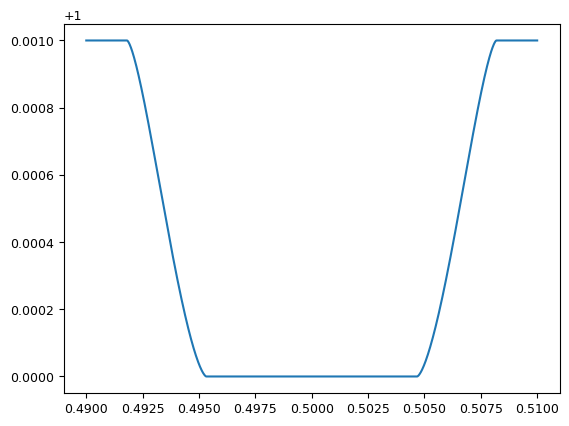

In [40]:
import batman
params = batman.TransitParams()       #object to store transit parameters
# params.t0 = 0.                        #time of inferior conjunction
params.per = 1.                       #orbital period
params.rp = 0.1                       #planet radius (in units of stellar radii)
params.a = 15.                        #semi-major axis (in units of stellar radii)
params.inc = 87.                      #orbital inclination (in degrees)
params.ecc = 0.                       #eccentricity
params.w = 90.                        #longitude of periastron (in degrees)
# params.limb_dark = "nonlinear"  # worked      #limb darkening model
# params.u = [0.5, 0.1, 0.1, -0.1]  # worked with  "nonlinear"
params.limb_dark = "uniform"
params.u = []
# params.u = [0.5, 0.1]      #limb darkening coefficients [u1, u2, u3, u4]    # original

params.fp = 0.001
params.t_secondary = 0.5
t = np.linspace(0.49, 0.51, 1000)

m = batman.TransitModel(params, t, transittype="secondary")
flux = m.light_curve(params)
plt.plot(t, flux)
# plt.ylim(0.9996, 1.0014)

In [ ]:
# Kepler-10b

import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import batman

# Search for Kepler-10 light curve (KIC 8494142)
search_result = lk.search_lightcurve("KIC 8494142", mission="Kepler", quarter=3)  # Start with Q1
lc = search_result.download().remove_outliers().normalize()  # Downloads the PDCSAP flux (pre-processed)

# Extract time and flux
t = lc.time.value  # Time in BKJD (Barycentric Kepler Julian Date)
flux = lc.flux.value  # Normalized flux
flux_err = lc.flux_err.value  # Flux uncertainty

# Convert BKJD to relative time around secondary eclipse
# Kepler-10b's period = 0.837495 days, t_secondary ~ 0.41875 days from t0
t0 = t[0]  # Reference time (start of light curve)
t_relative = t - t0  # Relative time in days

# Orbital period of Kepler-10b
period = 0.837495  # days
t_secondary = 0.41875  # Approximate time of secondary eclipse in first orbit

# Fold the time series at the period
phase = (t_relative % period) / period
mask = (phase > 0.45) & (phase < 0.55)  # Window around phase 0.5 (±0.05)

# Extract time, flux, and errors around secondary eclipse
t_eclipse = t_relative[mask]
flux_eclipse = flux[mask]
flux_err_eclipse = flux_err[mask]

# Define batman parameters for Kepler-10b
params = batman.TransitParams()
params.per = 0.837495         # orbital period (days)
params.rp = 0.01255           # planet radius (stellar radii)
params.a = 4.35               # semi-major axis (stellar radii)
params.inc = 84.4             # inclination (degrees)
params.ecc = 0.0              # eccentricity
params.w = 90.0               # longitude of periastron
params.limb_dark = "quadratic" # limb darkening model
params.u = [0.4, 0.2]         # limb darkening coefficients
params.fp = 8*10**(-4.5)              # secondary eclipse depth (8 ppm)
params.t_secondary = t_eclipse[0] + (t_secondary - t_eclipse[0] % period)  # Align to nearest eclipse

# Initialize and compute model
m = batman.TransitModel(params, t_eclipse, transittype="secondary")
flux_model = m.light_curve(params) - 0.0002529822128134/2

# # Plot
# plt.figure(figsize=(10, 6))
# # plt.errorbar(t_eclipse, flux_eclipse, yerr=flux_err_eclipse, fmt=".k", label="Kepler Data", alpha=0.5)
# # plt.plot(t_eclipse, flux_eclipse, '.--')
# plt.plot(t_eclipse, flux_model, "r-", label="Model (8 ppm depth)")
# plt.xlabel("Time (days relative to start)")
# plt.ylabel("Relative Flux")
# # plt.ylim(min(flux_eclipse) - 0.00005, max(flux_eclipse) + 0.00005)  # Zoom in
# plt.xlim(0, 20)
# plt.legend()
# plt.title("Kepler-10b Secondary Eclipse (Q1 Data)")
# plt.show()

# # Print depth
# print(f"Modeled eclipse depth: {params.fp * 1e6:.1f} ppm")